In [1]:
from typing import TypedDict ,List ,Union
from langchain_core.messages import HumanMessage ,AIMessage
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph ,START ,END
from dotenv import load_dotenv
from typing import Annotated , Sequence ,TypedDict
from langchain_core.messages import BaseMessage ,ToolMessage ,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph  ,END ,START
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model

In [2]:
import os
import pandas as pd
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.llms import Ollama
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.output_parsers import StrOutputParser

from typing import Annotated , Sequence ,TypedDict
from langchain_core.messages import BaseMessage ,ToolMessage ,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph  ,END ,START
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model


import operator
from typing import TypedDict, Sequence, Annotated

# Import necessary components from langchain and langgraph
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
# Assuming init_chat_model is a placeholder, using ChatOllama as an example
from langchain_community.chat_models import ChatOllama
from langchain_core.tools import tool # Correct import for @tool decorator
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [3]:
llm = init_chat_model(
    model="llama3.1:latest ",#"phi3.5:latest",#phi3.5",  # The name of the model in Ollama #'deepseek-r1:1.5b',# llama3.2:latest phi3.5:latest 
    model_provider="ollama",  # Explicitly state the provider
    temperature=0.7,  # Optional: control creativity
    # base_url="http://localhost:11434" # Optional: If your Ollama is on a different host/port
)

In [4]:
PDF_PATH = 'The styrene production.pdf'#'Production_of_Cumene_from_Benzene_Propylene.pdf'#"eg_asp.pdf"#"IPA1.pdf"
LLM_MODEL ='llama3.2:3b'#'deepseek-r1:1.5b'#"llama3.1:latest" #"llama3.2:3b"#"llama3.2:latest",#"phi3.5:latest",# "llama3.1:latest" #
EMBEDDING_MODEL ="mxbai-embed-large"# "snowflake-arctic-embed:33m"#

In [5]:


def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating/updating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    # Create a directory name based on the PDF file name
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"

    # Check if the vector store already exists
    if os.path.exists(persist_directory) and os.listdir(persist_directory):
        print(f"A RAG vector store for '{db_name}' already exists at '{persist_directory}'.")
        choice = input("Do you want to (a)dd to it, (r)emove and replace it, or (c)ontinue with old RAG? (a/r/c): ").lower()
        
        if choice == 'r':
            print(f"Removing old vector store and creating a new one...")
            # Remove existing directory and its contents
            shutil.rmtree(persist_directory)
            print("Old vector store removed.")
            
            # Load and process the new PDF
            loader = PyPDFLoader(pdf_path)
            documents = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
            docs = text_splitter.split_documents(documents)

            if not docs:
                print("Error: The PDF file is empty or could not be processed.")
                return None
            
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            vector_store = Chroma.from_documents(
                documents=docs,
                embedding=embeddings,
                persist_directory=persist_directory
            )
        elif choice == 'a':
            print("Adding documents to the existing vector store...")
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            # Load the existing vector store
            vector_store = Chroma(
                persist_directory=persist_directory,
                embedding_function=embeddings
            )
            # Load and process the new PDF to add to the existing store
            loader = PyPDFLoader(pdf_path)
            documents = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
            docs = text_splitter.split_documents(documents)

            if not docs:
                print("Error: The new PDF file is empty or could not be processed.")
                return None
            
            vector_store.add_documents(documents=docs)
            print("Documents added successfully.")
        elif choice == 'c':
            print("Continuing with the existing vector store...")
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            # Load the existing vector store without making changes
            vector_store = Chroma(
                persist_directory=persist_directory,
                embedding_function=embeddings
            )
        else:
            print("Invalid choice. Operation cancelled.")
            return None
    else:
        print(f"Creating a new ChromaDB vector store for '{db_name}' at '{persist_directory}'...")
        loader = PyPDFLoader(pdf_path)
        documents = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
        docs = text_splitter.split_documents(documents)

        if not docs:
            print("Error: The PDF file is empty or could not be processed.")
            return None

        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma.from_documents(
            documents=docs,
            embedding=embeddings,
            persist_directory=persist_directory
        )
        print("New vector store created successfully.")

    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = Ollama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain



In [6]:
def chat_with_pdf():
    """
    Main function to run the PDF chatbot.
    """
    rag_chain = setup_rag_chain(PDF_PATH)
    
    if rag_chain is None:
        return

    print("\n-------------------------------------------")
    print(f"Chatbot is ready. You can now ask questions about '{os.path.basename(PDF_PATH)}'.")
    print("Type 'exit' to quit.")
    print("-------------------------------------------")
    
    while True:
        user_question = input("\nYour question: ")
        if user_question.lower() == 'exit':
            print("Goodbye!")
            break
        
        print("Thinking...")
        try:
            response = rag_chain.invoke(user_question)
            print(f"\nChatbot: {response}")
        except Exception as e:
            print(f"An error occurred: {e}")
            print("Please make sure the Ollama server is running and the models are pulled.")
            break

In [7]:
chat_with_pdf()

A RAG vector store for 'The styrene production' already exists at './The styrene production_rag_db'.


Do you want to (a)dd to it, (r)emove and replace it, or (c)ontinue with old RAG? (a/r/c):  exit


Invalid choice. Operation cancelled.


In [ ]:
# show all the chemicals in this process including inlet , outlet and unreacted compounds

# give a list of all the chemicals involved in this process combining inlet , outlet or any un involved chemicals

# composition of the chemicals in the inlet stream 

# inlet condition of the stream like temperature , pressure and flowrate 

 # inlet temperature of the stream of the stream is pretreated like preheating consider the inlet temperature as the atmospheric temperature 25C

# inlet temperature of the stream of the stream is pretreated like preheating consider the inlet temperature as the atmospheric temperature 25C, what is the inlet temperature

# what are the equipments used in the process include all the hidden equipments 

# consider you are modeling the process using the list of equipemnts availbe with you which are Heater , pump , reactor , cooler , value and distillation columns arrange the models with the streams to connect the equipemnts

# what is the inlet temperature , if the actual temperature is not given consider it as 25C

# consider you are modeling the process using the list of equipemnts availbe with you which are Heater , pump , reactor , cooler , value and distillation columns arrange the models with the streams to connect the equipemnts.if the input conditions are not specifed consider it is in atmospheric condition . temperature is 25C and pressure is 1 bar

In [8]:
@tool
def stream(name:str,temperature:float,pressure:float,chemicals_list:list,chemical_fraction:dict,flow:float):
    """Stream function is used to define the stream  
    name = name of the stream
    temperature = temperature of the stream
    pressure=pressure of the stream,
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals 
    flow= flowrate of the stream mole flow 
    """
    mole_frac={}
    for i in chemicals_list:
        if i in chemical_fraction.keys():
            mole_frac[i] = chemical_fraction[0]
        else:
            mole_frac[i] = 0
    stream={
        'Name': name, 
 'Temperature (K)': temperature, 
 'Pressure (Pa)': pressure,
 'Molar Flowrate (mol/s)': flow,
    'Mole Fraction':mole_frac
    }
    return stream
@tool
def heater(inlet_stream:dict,heater_type:str,condition:float,name=str):
    """Heater is a heating unit where the temperature of the inlet stream is increased 
    inlet_stream = stream class is sent as 
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference 
    name=Name of the outlet stream from the heater
    """
    # heat_capacity=inlet_stream.cp()
    # flow_rate=inlet_stream.flow()
    outlet_stream=inlet_stream.copy()
    if heater_type =='outlet_temperature':
        outlet_temp= condition
        temperature_diff= condition -inlet_stream['Temperature (K)'] 
    else:
        temperature_diff=condition
        outlet_temp= inlet_stream['Temperature (K)'] +condition
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*temperature_diff
    outlet_stream['Temperature (K)']=outlet_temp
    outlet_stream['Name']=name
    return  ioutlet_stream

@tool
def pump(inlet_stream:dict,pump_condition:str,value:float,name:str):
    """Pump is a pumping unit where the pressure of the inlet stream is increased 
    inlet_stream = stream dict is sent 
    pump_condition=pump condition based on data whether 'outlet_pressure' or 'pressure_difference' is given in the data,
    value=value of outlet temperature or temperature difference 
    """
    outlet_stream=inlet_stream.copy()
    if pump_condition =='outlet_pressure':
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 
    else:
        prespressuresure_diff=value
        outlet_temp= inlet_stream['Pressure (Pa)'] +value
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*100
    outlet_stream['Pressure (Pa)']=outlet_temp
    outlet_stream['Name']=name
    return  outlet_stream

@tool
def Flash(inlet_stream:dict,pressure_drop:bool,value=0,gas_name=str,liq_name=str):
    """Flash is a stream seperator into liquid and vapor  
    inlet_stream = stream dict is sent 
    pressure_drop=to specify there is pressure changes in flash unit if true specify the pressure in flash,
    value=when the pressure drop is true specify the pressure in flash tank  
    """
    if pressure_drop ==True:
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 

    inlet_stream['Pressure (Pa)']=outlet_temp
    inlet_stream1=inlet_stream.copy()
    inlet_stream1['Name']=gas_name
    inlet_stream2=inlet_stream.copy()
    inlet_stream2['Name']=liq_name

    return  inlet_stream1 ,inlet_stream2

@tool
def Reactor(inlet_stream:dict,Reaction_stoichiometry:dict,conversion=float,name=str):
    """Reactor is a  conversion reactpor 
    stream = reactor inlet stream (containing temperature , pressure , mole flow , mole fraction and other detail) 
    Reaction_stoichiometry = in a order structure chemicals involved in dictionary as key and the stoichimetry coefficient as value for reactant its negative and product its positive,
    conversion=conversion percentage of the reaction
    name= name of the outlet stream from reactor
    """
    outlet_stream=inlet_stream.copy()
    print('conversion',conversion)
    print('Reaction_stoichiometry')
    outlet_stream['conversion']=conversion
    outlet_stream['Reaction_stoichiometry']=Reaction_stoichiometry
    outlet_stream['Name']=name
    return  outlet_stream

In [5]:
import operator
from typing import TypedDict, Sequence, Annotated

# Import necessary components from langchain and langgraph
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_community.chat_models import ChatOllama
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode


# # Import necessary components from langchain and langgraph
# from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
# # Assuming init_chat_model is a placeholder, using ChatOllama as an example
# from langchain_community.chat_models import ChatOllama
# from langchain_core.tools import tool # Correct import for @tool decorator
# from langgraph.graph import StateGraph, START, END
# from langgraph.prebuilt import ToolNode


In [9]:

# 1. AgentState with correct key
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# 2. Corrected tool definitions (typo fix)
@tool
def simulation(content: str) -> str:
    """function is run if the user want to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def general_discussion(content: str) -> str:
    """This is a general discussion function if the user wants to enquire anything other than the details in the paper or related to the simulation."""
    print('General discussion')
    return 'General discussion is done'

tools = [simulation, enquiry_about_process, general_discussion]

# 3. LLM initialization
llm = init_chat_model(
    model='llama3.2:3b',#'llama3.1:latest',
    model_provider="ollama",
    temperature=0.7,
).bind_tools(tools)

# 4. Corrected agent1 function
def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')
    system_prompt = SystemMessage(content=f'''
    You are a chemical expert helping with chemical processes and simulations.
    - If the user wants to discuss anything general, use the general_discussion tool.
    - If the user wants to enquire about the process in the paper for Ethyl benzene, use the tool enquiry_about_process.
    - If the user wants to do a simulation or enquire about a simulation, then use the tool simulation.
    ''')
    
    all_messages = [system_prompt] + state['messages']
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    
    return {'messages': [response]}

# 5. Corrected should_continue function
def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not last_message.tool_calls:
        # No tool calls, so the agent has a final response
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        # Tool calls exist, so continue to the tools node
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

# 6. Corrected print_messages function and variable name
def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

# 7. Building the graph with correct node names
graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

# 8. Corrected run_document_agent function
def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    # Store chat history in a list
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        # Append the new user message to the conversation history
        messages.append(HumanMessage(content=user_input))
        
        # Invoke the graph with the current state to get a single turn response
        result = app.invoke({'messages': messages})
        
        # Print only the new messages from the assistant and tools
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        # Update the messages list with the full conversation history from the result
        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is distillation column


---AGENT 1: INVOKED---
LLM Response: 
USING TOOLS: ['general_discussion']
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
General discussion
ASSISTANT: 
TOOL RESULT: General discussion is done


What would you like to do next?  what is the ethyl glycol process


---AGENT 1: INVOKED---
LLM Response: 
USING TOOLS: ['enquiry_about_process']
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Process is enquired
ASSISTANT: 
TOOL RESULT: Enquiry is done


What would you like to do next?  simualate the process


---AGENT 1: INVOKED---
LLM Response: 
USING TOOLS: ['simulation']
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Process simulated
ASSISTANT: 
TOOL RESULT: simulation is done


What would you like to do next?  exit


In [15]:
def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating/updating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    # Create a directory name based on the PDF file name
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"

    # Check if the vector store already exists
    if os.path.exists(persist_directory) and os.listdir(persist_directory):
        print(f"A RAG vector store for '{db_name}' already exists at '{persist_directory}'.")
        # choice = input("Do you want to (a)dd to it, (r)emove and replace it, or (c)ontinue with old RAG? (a/r/c): ").lower()
        
        print("Continuing with the existing vector store...")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        # Load the existing vector store without making changes
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )



    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = Ollama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain


def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"
    
    # Check if the vector store already exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        # NOTE: You need to have PyPDFLoader and RecursiveCharacterTextSplitter for this partex
        from langchain_community.document_loaders import PyPDFLoader
        from langchain_text_splitters import RecursiveCharacterTextSplitter

        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        splits = text_splitter.split_documents(docs)
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma.from_documents(
            documents=splits,
            embedding=embeddings,
            persist_directory=persist_directory
        )
        print(f"Vector store created at '{persist_directory}'.")
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = Ollama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

def chat_with_pdf():
    """
    Main function to run the PDF chatbot.
    """
    rag_chain = setup_rag_chain(PDF_PATH)

    while True:
        user_question = input("\nYour question: ")
        if user_question.lower() == 'exit':
            print("Goodbye!")
            break
        
        print("Thinking...")
        try:
            response = rag_chain.invoke(user_question)
            print(f"\nChatbot: {response}")
        except Exception as e:
            print(f"An error occurred: {e}")
            print("Please make sure the Ollama server is running and the models are pulled.")
            break


if __name__ == "__main__":

    chat_with_pdf()

Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.



Your question:  explain the process


Thinking...

Chatbot: I'm ready to help with the explanation. Please provide the question and the relevant context. I'll do my best to provide a clear and accurate response. If I don't know the answer, I'll say so. Let's get started!



Your question:  what is the steps to produce styrene


Thinking...

Chatbot: I don't know the specific steps to produce styrene. However, I can provide a general overview of the production process.

Styrene is typically produced through the alkylation of benzene with ethylene in the presence of an aluminum alkyl conjugate catalyst, followed by hydrogenation to form methylstyrene. The reaction can be represented by the following equation:

C6H6 + C2H4 → C6H5CH=CH2

The actual process may involve additional steps such as purification, drying, and storing the final product.

If you need more detailed information or specific requirements for styrene production, I recommend consulting a reliable source or an expert in the field.



Your question:  exit


Goodbye!


In [10]:
def stream(name:str,temperature:float,pressure:float,chemicals_list:list,chemical_fraction:dict,flow:float):
    """Stream function is used to define the stream  
    name = name of the stream
    temperature = temperature of the stream
    pressure=pressure of the stream,
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals 
    flow= flowrate of the stream mole flow 
    """
    mole_frac={}
    for i in chemicals_list:
        if i in chemical_fraction.keys():
            mole_frac[i] = chemical_fraction[0]
        else:
            mole_frac[i] = 0
    stream={
        'Name': name, 
 'Temperature (K)': temperature, 
 'Pressure (Pa)': pressure,
 'Molar Flowrate (mol/s)': flow,
    'Mole Fraction':mole_frac
    }
    return stream

def heater(inlet_stream:dict,heater_type:str,condition:float,name=str):
    """Heater is a heating unit where the temperature of the inlet stream is increased 
    inlet_stream = stream class is sent as 
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference 
    name=Name of the outlet stream from the heater
    """
    # heat_capacity=inlet_stream.cp()
    # flow_rate=inlet_stream.flow()
    outlet_stream=inlet_stream.copy()
    if heater_type =='outlet_temperature':
        outlet_temp= condition
        temperature_diff= condition -inlet_stream['Temperature (K)'] 
    else:
        temperature_diff=condition
        outlet_temp= inlet_stream['Temperature (K)'] +condition
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*temperature_diff
    outlet_stream['Temperature (K)']=outlet_temp
    outlet_stream['Name']=name
    return  ioutlet_stream

def pump(inlet_stream:dict,pump_condition:str,value:float,name:str):
    """Pump is a pumping unit where the pressure of the inlet stream is increased 
    inlet_stream = stream dict is sent 
    pump_condition=pump condition based on data whether 'outlet_pressure' or 'pressure_difference' is given in the data,
    value=value of outlet temperature or temperature difference 
    """
    outlet_stream=inlet_stream.copy()
    if pump_condition =='outlet_pressure':
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 
    else:
        prespressuresure_diff=value
        outlet_temp= inlet_stream['Pressure (Pa)'] +value
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*100
    outlet_stream['Pressure (Pa)']=outlet_temp
    outlet_stream['Name']=name
    return  outlet_stream

def Flash(inlet_stream:dict,pressure_drop:bool,value=0,gas_name=str,liq_name=str):
    """Flash is a stream seperator into liquid and vapor  
    inlet_stream = stream dict is sent 
    pressure_drop=to specify there is pressure changes in flash unit if true specify the pressure in flash,
    value=when the pressure drop is true specify the pressure in flash tank  
    """
    if pressure_drop ==True:
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 

    inlet_stream['Pressure (Pa)']=outlet_temp
    inlet_stream1=inlet_stream.copy()
    inlet_stream1['Name']=gas_name
    inlet_stream2=inlet_stream.copy()
    inlet_stream2['Name']=liq_name

    return  inlet_stream1 ,inlet_stream2

def Reactor(inlet_stream:dict,Reaction_stoichiometry:dict,conversion=float,name=str):
    """Reactor is a  conversion reactpor 
    stream = reactor inlet stream (containing temperature , pressure , mole flow , mole fraction and other detail) 
    Reaction_stoichiometry = in a order structure chemicals involved in dictionary as key and the stoichimetry coefficient as value for reactant its negative and product its positive,
    conversion=conversion percentage of the reaction
    name= name of the outlet stream from reactor
    """
    outlet_stream=inlet_stream.copy()
    print('conversion',conversion)
    print('Reaction_stoichiometry')
    outlet_stream['conversion']=conversion
    outlet_stream['Reaction_stoichiometry']=Reaction_stoichiometry
    outlet_stream['Name']=name
    return  outlet_stream

In [ ]:
class stream_spec():
    def __init__(self,name,Temperature:float,pressure:float,composition:list,flow_rate:list)
        self.name=name
        self.Temperature=Temperature
        self.pressure=pressure
        self.composition=composition
        self.flow_rate=flow_rate

def heater(name:str,inlet_stream:class,heater_type:str,condition:float):
    """Heater is a heating unit where the temperature of the inlet stream is increased 
    name = name of the heater unit 
    inlet_stream = stream class is sent as 
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference 
    """
    flow_rate=inlet_stream.flow_rate()
    if heater_type =='outlet_temperature':
        temperature_out=inlet_stream.Temperature() - condition
    else:
        temperature_out=condition + condition
    heater=stream_spec(f'{name}_outlet',temperature_out,inlet_stream.pressure(),inlet_stream.composition(),inlet_stream.flow_rate())
     return heater

def pump(name:str,inlet_stream:class,heater_type:str,condition:float):
    """Heater is a heating unit where the temperature of the inlet stream is increased 
    name = name of the heater unit 
    inlet_stream = stream class is sent as 
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference 
    """
    flow_rate=inlet_stream.flow_rate()
    if heater_type =='outlet_temperature':
        temperature_out=inlet_stream.Temperature() - condition
    else:
        temperature_out=condition + condition
    heater=stream_spec(f'{name}_outlet',temperature_out,inlet_stream.pressure(),inlet_stream.composition(),inlet_stream.flow_rate())
     return heater

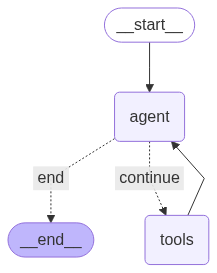

In [18]:
from IPython.display import Image,display

display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
# import os
# from typing import TypedDict, Annotated, Sequence
# from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.runnables import RunnablePassthrough
# from langchain_core.output_parsers import StrOutputParser
# from langchain_community.chat_models import ChatOllama
# from langchain_community.llms import Ollama
# from langchain_community.embeddings import OllamaEmbeddings
# from langchain_community.document_loaders import PyPDFLoader
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_community.vectorstores import Chroma
# from langchain_core.tools import tool
# from langgraph.graph import StateGraph, END, START
# from langgraph.prebuilt import ToolNode

# # --- 1. CONFIGURATION AND MODEL SETUP ---
# # NOTE: Set the correct path to your PDF and models
# PDF_PATH = "./Ethyl_benzene_paper.pdf"
# LLM_MODEL = 'llama3.2:3b'
# EMBEDDING_MODEL = 'nomic-embed-text'

PDF_PATH = 'The styrene production.pdf'#'Production_of_Cumene_from_Benzene_Propylene.pdf'#"eg_asp.pdf"#"IPA1.pdf"
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

# --- 2. RAG COMPONENTS ---
def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.
    """
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"

    # Check if the vector store exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        splits = text_splitter.split_documents(docs)
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma.from_documents(
            documents=splits,
            embedding=embeddings,
            persist_directory=persist_directory
        )
        print(f"Vector store created at '{persist_directory}'.")
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = Ollama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    return rag_chain

# --- 3. AGENT STATE AND TOOL DEFINITIONS ---
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], lambda x: x]

# Initialize the RAG chain globally so tools can access it
try:
    rag_chain = setup_rag_chain(PDF_PATH)
except FileNotFoundError:
    print(f"Error: PDF file not found at '{PDF_PATH}'. Please check the path and try again.")
    rag_chain = None

@tool
def simulation(content: str) -> str:
    """function is run if the user want to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper. 
    paper summary is Styrene is synthesized through a process that begins with an equimolar feed of benzene and ethylene,
    which is preheated to 95°C at 1.01325 bar and then pressurized to 13 bar in a pump. The feed enters a conversion reactor 
    where ethyl benzene is produced with a 70% conversion rate based on benzene,
    which is then purified through distillation columns to produce styrene."""
    if rag_chain is None:
        return "I'm sorry, the document is not available. Please ensure the PDF file exists."
    
    print('Sending question to RAG chain...')
    response = rag_chain.invoke(content)
    return response

@tool
def general_discussion(content: str) -> str:
    """This is a general discussion function if the user wants to enquire anything other than the details in the paper or related to the simulation."""
    print('Sending question to general LLM...')
    # Using the same LLM from the agent for consistency
    llm = ChatOllama(model=LLM_MODEL)
    response = llm.invoke(content).content
    return response

tools = [simulation, enquiry_about_process, general_discussion]

# --- 4. AGENT FUNCTIONS (UNCHANGED) ---
def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')
    llm = ChatOllama(model=LLM_MODEL).bind_tools(tools)
    system_prompt = SystemMessage(content=f'''
    You are a chemical expert helping with chemical processes and simulations.
    - If the user wants to discuss anything general, use the general_discussion tool.
    - If the user wants to enquire about the process in the paper for Ethyl benzene, use the tool enquiry_about_process.
    - If the user wants to do a simulation or enquire about a simulation, then use the tool simulation.
    ''')
    
    all_messages = [system_prompt] + state['messages']
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    
    return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

# --- 5. GRAPH BUILDING AND EXECUTION ---
graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', 'agent') # Changed edge to loop back to the agent for a new response

app = graph.compile()

# --- 6. UTILITY AND MAIN FUNCTIONS (MODIFIED) ---
def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant! 🔬")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)
        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.


ValueError: Invalid reducer signature. Expected (a, b) -> c. Got (x)

In [14]:

# --- 1. CONFIGURATION AND MODEL SETUP ---
PDF_PATH = 'The styrene production'
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

# --- 2. RAG COMPONENTS ---
def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.
    """
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"

    # NOTE: These imports were missing and have been added.
    from langchain_community.document_loaders import PyPDFLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    # Check if the vector store exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
        splits = text_splitter.split_documents(docs)
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma.from_documents(
            documents=splits,
            embedding=embeddings,
            persist_directory=persist_directory
        )
        print(f"Vector store created at '{persist_directory}'.")
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k": 5})
    llm = Ollama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    return rag_chain

# --- 3. AGENT STATE AND TOOL DEFINITIONS ---
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], lambda x: x]

# Initialize the RAG chain globally so tools can access it
try:
    rag_chain = setup_rag_chain(PDF_PATH)
except FileNotFoundError:
    print(f"Error: PDF file not found at '{PDF_PATH}'. Please check the path and try again.")
    rag_chain = None

@tool
def simulation(content: str) -> str:
    """function is run if the user want to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper. 
    paper summary is Styrene is synthesized through a process that begins with an equimolar feed of benzene and ethylene,
    which is preheated to 95°C at 1.01325 bar and then pressurized to 13 bar in a pump. The feed enters a conversion reactor 
    where ethyl benzene is produced with a 70% conversion rate based on benzene,
    which is then purified through distillation columns to produce styrene."""
    if rag_chain is None:
        return "I'm sorry, the document is not available. Please ensure the PDF file exists."
    
    print('Sending question to RAG chain...')
    response = rag_chain.invoke(content)
    return response

@tool
def general_discussion(content: str) -> str:
    """This is a general discussion function if the user wants to enquire anything other than the details in the paper or related to the simulation."""
    print('Sending question to general LLM...')
    # Using the same LLM from the agent for consistency
    llm = ChatOllama(model=LLM_MODEL)
    response = llm.invoke(content).content
    return response

tools = [simulation, enquiry_about_process, general_discussion]

# --- 4. AGENT FUNCTIONS (UNCHANGED) ---
def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')
    llm = ChatOllama(model=LLM_MODEL).bind_tools(tools)
    system_prompt = SystemMessage(content=f'''
    You are a chemical expert helping with chemical processes and simulations.
    - If the user wants to discuss anything general, use the general_discussion tool.
    - If the user wants to enquire about the process in the paper for Ethyl benzene, use the tool enquiry_about_process.
    - If the user wants to do a simulation or enquire about a simulation, then use the tool simulation.
    ''')
    
    all_messages = [system_prompt] + state['messages']
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    
    return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

# --- 5. GRAPH BUILDING AND EXECUTION ---
graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', 'agent')

app = graph.compile()

# --- 6. UTILITY AND MAIN FUNCTIONS (MODIFIED) ---
def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant! 🔬")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)
        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.


ValueError: Invalid reducer signature. Expected (a, b) -> c. Got (x)

In [16]:
# The original imports and AgentState definition remain the same
from typing import List, Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
from langchain_community.tools.tavily_search import TavilySearchResults

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def simulation(content: str) -> str:
    """function is run if the user want to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def general_discussion(content: str) -> str:
    """This is a general discussion function if the user wants to enquire anything other than the details in the paper or related to the simulation."""
    # Instantiate a new LLM model for this specific chat
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("General discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    # Store chat history for the discussion within the tool
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting general discussion.")
            return 'General discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        # Invoke the new LLM directly for the chat
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'General discussion is done'

tools = [simulation, enquiry_about_process, general_discussion]

# 3. The main LLM for tool-calling is now correctly bound to tools
llm = ChatOllama(model="llama3.2:3b", temperature=0.7).bind_tools(tools)

# The rest of the script remains the same
def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')
    system_prompt = SystemMessage(content=f'''
    You are a chemical expert helping with chemical processes and simulations.
    - If the user wants to discuss anything general, use the general_discussion tool.
    - If the user wants to enquire about the process in the paper for Ethyl benzene, use the tool enquiry_about_process.
    - If the user wants to do a simulation or enquire about a simulation, then use the tool simulation.
    ''')
    
    all_messages = [system_prompt] + state['messages']
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    if hasattr(response, "tool_calls") and response.tool_calls:
        print(f"USING TOOLS: {[tc['name'] for tc in response.tool_calls]}")
    
    return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

NotImplementedError: 

In [ ]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def simulation(content: str) -> str:
    """function is run if the user wants to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def other_discussion(content :str)-> str:
    "this function is run when the user enquires anything other not related to chemical engineering , process used in the paper or simualtion "
    print('Other chat')
    return 'sorry i can support only to chemical q

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation ."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("General discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting general discussion.")
            return 'General discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'General discussion is done'

tools = [simulation, enquiry_about_process, general_discussion]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    tool_descriptions = """
TOOLS:
- simulation: function is run if the user wants to simulate the process, usual command like start simulation, simulate the process.
- enquiry_about_process: This is an enquiry function if the user wants to enquire anything about the data in the paper.
- general_discussion: This is a general discussion function if the user wants to enquire about chmeicals and chemical engineering anything other than the details in the paper or related to the simulation.
-other_discussion : this is a function that run when the user enquires anything other not related to chemical engineering , process used in the paper or simualtion 
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text.
"""
    
    system_prompt_content = f'''
    You are a chemical expert helping with chemical processes and simulations.
    {tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    all_messages = [system_prompt] + state['messages']
    
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        # Create a mock tool call object with a unique ID
        tool_call = {
            "id": str(uuid.uuid4()), # Generate a unique ID
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        # The agent returns the tool call
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        # No tool call detected, so return the LLM's response directly
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is a distillation column


---AGENT 1: INVOKED---
LLM Response: <enquiry_about_process>
USING TOOL: enquiry_about_process
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Process is enquired
ASSISTANT: 
TOOL RESULT: Enquiry is done


In [10]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def simulation(content: str) -> str:
    """function is run if the user wants to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def other_discussion(content :str)-> str:
    "this function is run when the user enquires anything other not related to chemical engineering , process used in the paper or simualtion "
    print('Other chat')
    return 'sorry i can support only to chemical questions'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation ."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("Chemical discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting chemical discussion.")
            return 'Chemical discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'Chemical discussion is done'

# Corrected tool list to include the new functions
tools = [simulation, enquiry_about_process, chemical_discussion, other_discussion]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    # Corrected tool descriptions to match the new functions
    tool_descriptions = """
TOOLS:
- simulation: function is run if the user wants to simulate the process, usual command like start simulation, simulate the process.
- enquiry_about_process: This is an enquiry function if the user wants to enquire anything about the data in the paper.the summary of the paper 
is - Styrene is synthesised through a process that begins with an equimolar feed of benzene and ethylene, 
which is preheated to 95°C at 1.01325 bar and then pressurised to 13 bar in a pump. 
The feed enters a conversion reactor where ethyl benzene is produced with a 70% conversion rate based on benzene,
which is then purified through distillation columns to produce styrene.)
- chemical_discussion: This is a chemical discussion function if the user wants to enquire about chemicals and chemical engineering other than the details in the paper or related to the simulation.
- other_discussion: this is a function that run when the user enquires anything other not related to chemical engineering, process used in the paper or simulation.
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text.
"""
    
    system_prompt_content = f'''
    You are a chemical expert helping with chemical processes and simulations.
    {tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    all_messages = [system_prompt] + state['messages']
    
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        # Create a mock tool call object with a unique ID
        tool_call = {
            "id": str(uuid.uuid4()), # Generate a unique ID
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        # The agent returns the tool call
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        # No tool call detected, so return the LLM's response directly
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

C:\Users\Simreka_Employee\AppData\Local\Temp\ipykernel_10200\3283025233.py:65: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(model="llama3.2:3b", temperature=0.7)


Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is the capital of india


---AGENT 1: INVOKED---
LLM Response: <other_discussion>
USING TOOL: other_discussion
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Other chat
ASSISTANT: 
TOOL RESULT: sorry i can support only to chemical q


What would you like to do next?  what is the pressure of styrene production


---AGENT 1: INVOKED---


ValueError: Received unsupported message type for Ollama.

In [12]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def simulation(content: str) -> str:
    """function is run if the user wants to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def other_discussion(content :str)-> str:
    "this function is run when the user enquires anything other not related to chemical engineering , process used in the paper or simualtion "
    print('Other chat')
    return 'sorry i can support only to chemical q'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation ."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("Chemical discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting chemical discussion.")
            return 'Chemical discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'Chemical discussion is done'

# Corrected tool list
tools = [simulation, enquiry_about_process, chemical_discussion, other_discussion]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    tool_descriptions = """
TOOLS:
- simulation: function is run if the user wants to simulate the process, usual command like start simulation, simulate the process.
- enquiry_about_process: This is an enquiry function if the user wants to enquire anything about the data in the paper.And the summary of the paper is 
Styrene is synthesised through a process that begins with an equimolar feed of benzene and ethylene, 
which is preheated to 95°C at 1.01325 bar and then pressurised to 13 bar in a pump. 
The feed enters a conversion reactor where ethyl benzene is produced with a 70% conversion rate based on benzene,
which is then purified through distillation columns to produce styrene.)

- chemical_discussion: This is a chemical discussion function if the user wants to enquire about chemicals and chemical engineering other than the details in the paper or related to the simulation.
- other_discussion: this is a function that run when the user enquires anything other not related to chemical engineering, process used in the paper or simulation.

To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text.
"""
    
    system_prompt_content = f'''
    You are a chemical expert helping with chemical processes and simulations.
    {tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    # Filter messages to only include supported types for the LLM
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()), # Generate a unique ID
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is the pressure at which the styrene produced


---AGENT 1: INVOKED---
LLM Response: <process_details>
USING TOOL: process_details
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
ASSISTANT: 
TOOL RESULT: Error: process_details is not a valid tool, try one of [simulation, enquiry_about_process, chemical_discussion, other_discussion].


What would you like to do next?  exit


In [14]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def simulation(content: str) -> str:
    """function is run if the user wants to simulate the process, usual command like start simulation, simulate the process"""
    print('Process simulated')
    return 'simulation is done'

@tool
def other_discussion(content :str)-> str:
    "this function is run when the user enquires anything other not related to chemical engineering , process used in the paper or simualtion "
    print('Other chat')
    return 'sorry i can support only to chemical q'

@tool
def enquiry_about_process(content: str) -> str:
    """This is an enquiry function if the user wants to enquire anything about the data in the paper."""
    print('Process is enquired')
    return 'Enquiry is done'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation ."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("Chemical discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting chemical discussion.")
            return 'Chemical discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'Chemical discussion is done'

# Added a new tool alias to handle the LLM's hallucination
# This function simply calls the enquiry_about_process tool.
@tool
def process_details(content: str) -> str:
    """Use this tool when the user asks for specific details from the paper, like pressure, temperature, or flow rates."""
    return enquiry_about_process(content)

# Corrected tool list
tools = [simulation, enquiry_about_process, chemical_discussion, other_discussion, process_details]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    tool_descriptions = """
TOOLS:
- simulation: function is run if the user wants to simulate the process, usual command like start simulation, simulate the process.
- enquiry_about_process: This is an enquiry function if the user wants to enquire anything about the data in the paper.
- chemical_discussion: This is a chemical discussion function if the user wants to enquire about chemicals and chemical engineering other than the details in the paper or related to the simulation.
- other_discussion: this is a function that run when the user enquires anything other not related to chemical engineering, process used in the paper or simulation.
- process_details: Use this tool when the user asks for specific details from the paper, like pressure, temperature, or flow rates.
The summary of the paper is: Styrene is synthesised through a process that begins with an equimolar feed of benzene and ethylene, which is preheated to 95°C at 1.01325 bar and then pressurised to 13 bar in a pump. The feed enters a conversion reactor where ethyl benzene is produced with a 70% conversion rate based on benzene, which is then purified through distillation columns to produce styrene.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    
    system_prompt_content = f'''
    You are a chemical expert helping with chemical processes and simulations.
    {tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}
def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()

Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  simulate the process


---AGENT 1: INVOKED---
LLM Response: <simulation>
USING TOOL: simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Process simulated
ASSISTANT: 
TOOL RESULT: simulation is done


What would you like to do next?  what is distillation


---AGENT 1: INVOKED---
LLM Response: <chemical_discussion>
USING TOOL: chemical_discussion
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Chemical discussion mode activated. Type 'exit' or 'quit' to return to the main agent.


💬 You:  what is the chemical used in styrene production


🤖 Assistant: The primary chemicals used in styrene production are:

1. **Petroleum-based feedstocks**: The most common feedstock for styrene production is ethylene, which is derived from petroleum. Ethylene is a simple and abundant molecule that can be easily converted into styrene.
2. **Ethanol**: In some cases, ethanol (a bio-based molecule) can also be used as a feedstock to produce styrene through the solvent dehydrogenation process.

The chemical reaction involved in styrene production is:

C2H4 + H2 → C4H6

In this reaction, ethylene (C2H4) reacts with hydrogen gas (H2) in the presence of a catalyst to form styrene (C4H6).

Note that there are also other methods and feedstocks used to produce styrene, such as the production of styrene from propylene or butadiene. However, ethylene is by far the most common feedstock used in commercial styrene production.


💬 You:  exit


Exiting chemical discussion.
ASSISTANT: 
TOOL RESULT: Chemical discussion is done


What would you like to do next?  exit


In [5]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- Sub-Agent Tools ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper."""
    print('Enquiry is done')
    return 'Enquiry is done'

@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process."""
    print('Process simulated')
    return 'simulation is done'

# --- Top-Level Tools ---
@tool
def other_discussion(content: str) -> str:
    "This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."
    print('Other chat')
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("Chemical discussion mode activated. Type 'exit' or 'quit' to return to the main agent.")
    
    messages = [SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering.")]
    
    while True:
        user_input = input('💬 You: ')
        if user_input.lower() in ['exit', 'quit']:
            print("Exiting chemical discussion.")
            return 'Chemical discussion is done'

        messages.append(HumanMessage(content=user_input))
        
        response = discussion_llm.invoke(messages)
        messages.append(response)
        
        print(f"🤖 Assistant: {response.content}")

    return 'Chemical discussion is done'

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""

    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. You can answer questions based on a provided document or run a simulation.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]

    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            # The prompt is hard-coded into the tool, you can put the summary here
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        # If the sub-agent doesn't call a tool, it provides a direct answer
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()
    

C:\Users\Simreka_Employee\AppData\Local\Temp\ipykernel_12368\893010697.py:105: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import ChatOllama``.
  llm = ChatOllama(model="llama3.2:3b", temperature=0.7)


Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  explain the styrene production process


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---


C:\Users\Simreka_Employee\AppData\Local\Temp\ipykernel_12368\893010697.py:92: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return rag_enquiry(content)


Enquiry is done
ASSISTANT: 
TOOL RESULT: Enquiry is done


What would you like to do next?  exit


In [6]:
# Updated imports
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- Sub-Agent Tools (for the Styrene Process) ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper."""
    print('Enquiry is done')
    return 'Enquiry is done'

@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process."""
    print('Process simulated')
    return 'simulation is done'

# --- Top-Level Tools (for the Main Agent) ---
@tool
def other_discussion(content: str) -> str:
    """This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."""
    print('Other chat')
    # Returning the same reply as in the original code
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    print("Chemical discussion mode activated.")
    
    # A non-interactive version: invokes the LLM once and returns the response
    messages = [
        SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering."),
        HumanMessage(content=content)
    ]
    
    response = discussion_llm.invoke(messages)
    
    print(f"🤖 Assistant: {response.content}")
    return response.content

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model="llama3.2:3b", temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. Your task is to correctly route the user's request to one of the available tools.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]

    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            # The prompt is hard-coded into the tool, you can put the summary here
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        # If the sub-agent doesn't call a tool, it provides a direct answer
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model="llama3.2:3b", temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()
    


Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is gandhi


---AGENT 1: INVOKED---
LLM Response: <other_discussion>
USING TOOL: other_discussion
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Other chat
ASSISTANT: 
TOOL RESULT: sorry i can support only to chemical questions


What would you like to do next?  explain the styrene production process


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Enquiry is done
ASSISTANT: 
TOOL RESULT: Enquiry is done


What would you like to do next?  exit


In [6]:
# Updated imports for agent and RAG
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library
import os # For file path operations
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- RAG Setup ---
# Define constants for RAG
# PDF_PATH = "esterification-96-111.pdf"
# EMBEDDING_MODEL = "nomic-embed-text"
# LLM_MODEL = "llama3.2:3b"

PDF_PATH = 'The styrene production.pdf'#'Production_of_Cumene_from_Benzene_Propylene.pdf'#"eg_asp.pdf"#"IPA1.pdf"
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    # Create a directory name based on the PDF file name
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"
    
    # Check if the vector store already exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        try:
            loader = PyPDFLoader(pdf_path)
            docs = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
            splits = text_splitter.split_documents(docs)
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            vector_store = Chroma.from_documents(
                documents=splits,
                embedding=embeddings,
                persist_directory=persist_directory
            )
            print(f"Vector store created at '{persist_directory}'.")
        except Exception as e:
            print(f"Error creating vector store: {e}")
            print("Please ensure you have the required libraries (PyPDFLoader, RecursiveCharacterTextSplitter, etc.)")
            return None
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k":3})
    llm = ChatOllama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

# Initialize the RAG chain globally
RAG_CHAIN = setup_rag_chain(PDF_PATH)

# --- Sub-Agent Tools (for the Styrene Process) ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper."""
    print('RAG Enquiry is done')
    if RAG_CHAIN:
        try:
            response = RAG_CHAIN.invoke(content)
            return response
        except Exception as e:
            return f"An error occurred while running the RAG chain: {e}"
    else:
        return "RAG chain could not be initialized. Please check the PDF path and model setup."


@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process."""
    print('Process simulated')
    return 'simulation is done'

# --- Top-Level Tools (for the Main Agent) ---
@tool
def other_discussion(content: str) -> str:
    """This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."""
    print('Other chat')
    # Returning the same reply as in the original code
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    print("Chemical discussion mode activated.")
    
    # A non-interactive version: invokes the LLM once and returns the response
    messages = [
        SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering."),
        HumanMessage(content=content)
    ]
    
    response = discussion_llm.invoke(messages)
    
    print(f"🤖 Assistant: {response.content}")
    return response.content

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. Your task is to correctly route the user's request to one of the available tools.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]

    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            # The prompt is hard-coded into the tool, you can put the summary here
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        # If the sub-agent doesn't call a tool, it provides a direct answer
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model=LLM_MODEL, temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()
    


Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.


C:\Users\rkuma\AppData\Local\Temp\ipykernel_25072\723246522.py:73: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
C:\Users\rkuma\AppData\Local\Temp\ipykernel_25072\723246522.py:74: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vector_store = Chroma(
C:\Users\rkuma\AppData\Local\Temp\ipykernel_25072\723246522.py:80: LangChainDeprecationW

Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  what is apple price


---AGENT 1: INVOKED---
LLM Response: <other_discussion>
USING TOOL: other_discussion
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Other chat
ASSISTANT: 
TOOL RESULT: sorry i can support only to chemical questions


...

C:\Users\rkuma\AppData\Local\Temp\ipykernel_25072\723246522.py:181: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return rag_enquiry(content)


RAG Enquiry is done
ASSISTANT: 
TOOL RESULT: The styrene production process involves several steps:

1. **Feed preparation**: The process begins with an equi-molar feed of benzene (0.5) and ethylene (0.5), which is preheated to 95°C at a constant pressure of 1.01325 bar.
2. **Pumping**: The pressurized feed is sent to a pump to increase its pressure from 1.01325 bar to 13 bar.
3. **Conversion reactor**: The pressurized feed enters a conversion reactor, where ethyl benzene is produced with a 70% conversion rate based on benzene. This means that 70% of the benzene in the feed reacts with ethylene to form ethyl benzene, while the remaining 30% of benzene and all of the unreacted ethylene are carried over to the next step.
4. **Cooling**: The product stream from the reactor, containing ethyl benzene, unreacted ethylene, and benzene, is cooled to 150°C in a cooler.
5. **Distillation**: The cooled stream proceeds to a first distillation column, which separates purified ethyl benzene as the b

What would you like to do next?  simulate the process


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
Process simulated
ASSISTANT: 
TOOL RESULT: simulation is done


What would you like to do next?  exit


In [ ]:
@tool
def stream(name:str,temperature:float,pressure:float,chemicals_list:list,chemical_fraction:dict,flow:float):
    """Stream function is used to define the stream  
    name = name of the stream
    temperature = temperature of the stream
    pressure=pressure of the stream,
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals 
    flow= flowrate of the stream mole flow 
    """
    mole_frac={}
    for i in chemicals_list:
        if i in chemical_fraction.keys():
            mole_frac[i] = chemical_fraction[0]
        else:
            mole_frac[i] = 0
    stream={
        'Name': name, 
 'Temperature (K)': temperature, 
 'Pressure (Pa)': pressure,
 'Molar Flowrate (mol/s)': flow,
    'Mole Fraction':mole_frac
    }
    return stream
@tool
def heater(inlet_stream:dict,heater_type:str,condition:float,name=str):
    """Heater is a heating unit where the temperature of the inlet stream is increased 
    inlet_stream = stream class is sent as 
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference 
    name=Name of the outlet stream from the heater
    """
    # heat_capacity=inlet_stream.cp()
    # flow_rate=inlet_stream.flow()
    outlet_stream=inlet_stream.copy()
    if heater_type =='outlet_temperature':
        outlet_temp= condition
        temperature_diff= condition -inlet_stream['Temperature (K)'] 
    else:
        temperature_diff=condition
        outlet_temp= inlet_stream['Temperature (K)'] +condition
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*temperature_diff
    outlet_stream['Temperature (K)']=outlet_temp
    outlet_stream['Name']=name
    return  ioutlet_stream

@tool
def pump(inlet_stream:dict,pump_condition:str,value:float,name:str):
    """Pump is a pumping unit where the pressure of the inlet stream is increased 
    inlet_stream = stream dict is sent 
    pump_condition=pump condition based on data whether 'outlet_pressure' or 'pressure_difference' is given in the data,
    value=value of outlet temperature or temperature difference 
    """
    outlet_stream=inlet_stream.copy()
    if pump_condition =='outlet_pressure':
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 
    else:
        prespressuresure_diff=value
        outlet_temp= inlet_stream['Pressure (Pa)'] +value
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*100
    outlet_stream['Pressure (Pa)']=outlet_temp
    outlet_stream['Name']=name
    return  outlet_stream

@tool
def Flash(inlet_stream:dict,pressure_drop:bool,value=0,gas_name=str,liq_name=str):
    """Flash is a stream seperator into liquid and vapor  
    inlet_stream = stream dict is sent 
    pressure_drop=to specify there is pressure changes in flash unit if true specify the pressure in flash,
    value=when the pressure drop is true specify the pressure in flash tank  
    """
    if pressure_drop ==True:
        outlet_temp= value
        pressure_diff= value -inlet_stream['Pressure (Pa)'] 

    inlet_stream['Pressure (Pa)']=outlet_temp
    inlet_stream1=inlet_stream.copy()
    inlet_stream1['Name']=gas_name
    inlet_stream2=inlet_stream.copy()
    inlet_stream2['Name']=liq_name

    return  inlet_stream1 ,inlet_stream2

@tool
def Reactor(inlet_stream:dict,Reaction_stoichiometry:dict,conversion=float,name=str):
    """Reactor is a  conversion reactpor 
    stream = reactor inlet stream (containing temperature , pressure , mole flow , mole fraction and other detail) 
    Reaction_stoichiometry = in a order structure chemicals involved in dictionary as key and the stoichimetry coefficient as value for reactant its negative and product its positive,
    conversion=conversion percentage of the reaction
    name= name of the outlet stream from reactor
    """
    outlet_stream=inlet_stream.copy()
    print('conversion',conversion)
    print('Reaction_stoichiometry')
    outlet_stream['conversion']=conversion
    outlet_stream['Reaction_stoichiometry']=Reaction_stoichiometry
    outlet_stream['Name']=name
    return  outlet_stream

In [ ]:
# Updated imports for agent and RAG
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library
import os # For file path operations
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- RAG Setup ---
# Define constants for RAG
# PDF_PATH = "esterification-96-111.pdf"
# EMBEDDING_MODEL = "nomic-embed-text"
# LLM_MODEL = "llama3.2:3b"

PDF_PATH = 'The styrene production.pdf'
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    # Create a directory name based on the PDF file name
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"
    
    # Check if the vector store already exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        try:
            loader = PyPDFLoader(pdf_path)
            docs = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
            splits = text_splitter.split_documents(docs)
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            vector_store = Chroma.from_documents(
                documents=splits,
                embedding=embeddings,
                persist_directory=persist_directory
            )
            print(f"Vector store created at '{persist_directory}'.")
        except Exception as e:
            print(f"Error creating vector store: {e}")
            print("Please ensure you have the required libraries (PyPDFLoader, RecursiveCharacterTextSplitter, etc.)")
            return None
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k":3})
    llm = ChatOllama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

# Initialize the RAG chain globally
RAG_CHAIN = setup_rag_chain(PDF_PATH)

# --- Sub-Agent Tools (for the Styrene Process) ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper."""
    print('RAG Enquiry is done')
    if RAG_CHAIN:
        try:
            response = RAG_CHAIN.invoke(content)
            return response
        except Exception as e:
            return f"An error occurred while running the RAG chain: {e}"
    else:
        return "RAG chain could not be initialized. Please check the PDF path and model setup."

@tool
def stream(name:str,temperature:float,pressure:float,chemicals_list:list,chemical_fraction:dict,flow:float):
    """Stream function is used to define the stream  
    name = name of the stream
    temperature = temperature of the stream
    pressure=pressure of the stream,
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals 
    flow= flowrate of the stream mole flow 
    """
    mole_frac={}
    for i in chemicals_list:
        if i in chemical_fraction.keys():
            mole_frac[i] = chemical_fraction[i]
        else:
            mole_frac[i] = 0
    stream_dict={
        'Name': name, 
        'Temperature (K)': temperature, 
        'Pressure (Pa)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction':mole_frac
    }
    return stream_dict

@tool
def heater(inlet_stream:dict,heater_type:str,condition:float,name=str):
    """Heater is a heating unit where the temperature of the inlet stream is increased  
    inlet_stream = stream class is sent as  
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference  
    name=Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    
    # Placeholder for a more complex heat calculation
    # energy = inlet_stream['Molar Flowrate (mol/s)'] * 4.31 * temperature_diff
    
    if heater_type =='outlet_temperature':
        outlet_temp = condition
        temperature_diff = condition - inlet_stream['Temperature (K)'] 
    else:
        temperature_diff = condition
        outlet_temp = inlet_stream['Temperature (K)'] + condition
        
    energy = inlet_stream['Molar Flowrate (mol/s)']*4.31*temperature_diff
    outlet_stream['Temperature (K)'] = outlet_temp
    outlet_stream['Name'] = name
    return outlet_stream

@tool
def pump(inlet_stream:dict,pump_condition:str,value:float,name:str):
    """Pump is a pumping unit where the pressure of the inlet stream is increased  
    inlet_stream = stream dict is sent  
    pump_condition=pump condition based on data whether 'outlet_pressure' or 'pressure_difference' is given in the data,
    value=value of outlet temperature or temperature difference  
    name=Name of the outlet stream from the heater
    """
    outlet_stream=inlet_stream.copy()
    if pump_condition =='outlet_pressure':
        outlet_pressure = value
        pressure_diff = value - inlet_stream['Pressure (Pa)'] 
    else:
        pressure_diff = value
        outlet_pressure = inlet_stream['Pressure (Pa)'] + value
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*100
    outlet_stream['Pressure (Pa)']=outlet_pressure
    outlet_stream['Name']=name
    return  outlet_stream

@tool
def Flash(inlet_stream:dict,pressure_drop:bool,value=0,gas_name=str,liq_name=str):
    """Flash is a stream seperator into liquid and vapor  
    inlet_stream = stream dict is sent  
    pressure_drop=to specify there is pressure changes in flash unit if true specify the pressure in flash,
    value=when the pressure drop is true specify the pressure in flash tank  
    gas_name=Name of the outlet vapor stream from the flash
    liq_name=Name of the outlet liquid stream from the flash
    """
    outlet_temp = inlet_stream['Temperature (K)']
    if pressure_drop == True:
        pressure_diff = value - inlet_stream['Pressure (Pa)']
        outlet_temp = value
        
    inlet_stream['Pressure (Pa)'] = outlet_temp
    inlet_stream1 = inlet_stream.copy()
    inlet_stream1['Name'] = gas_name
    inlet_stream2 = inlet_stream.copy()
    inlet_stream2['Name'] = liq_name

    # Mock separation: 50/50 split for demonstration
    inlet_stream1['Molar Flowrate (mol/s)'] = inlet_stream1['Molar Flowrate (mol/s)'] * 0.5
    inlet_stream2['Molar Flowrate (mol/s)'] = inlet_stream2['Molar Flowrate (mol/s)'] * 0.5

    return inlet_stream1, inlet_stream2

@tool
def Reactor(inlet_stream:dict,Reaction_stoichiometry:dict,conversion=float,name=str):
    """Reactor is a conversion reactpor
    stream = reactor inlet stream (containing temperature , pressure , mole flow , mole fraction and other detail)
    Reaction_stoichiometry = in a order structure chemicals involved in dictionary as key and the stoichimetry coefficient as value for reactant its negative and product its positive,
    conversion=conversion percentage of the reaction
    name= name of the outlet stream from reactor
    """
    outlet_stream=inlet_stream.copy()
    print('conversion',conversion)
    print('Reaction_stoichiometry')
    outlet_stream['conversion']=conversion
    outlet_stream['Reaction_stoichiometry']=Reaction_stoichiometry
    outlet_stream['Name']=name
    return  outlet_stream

@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process step-by-step.
    It orchestrates calls to other equipment tools based on a detailed process description from RAG."""
    print('---Simulation Tool: Starting Dynamic Process Simulation---')

    # Step 1: Get the process description from the RAG tool.
    print("Step 1: Retrieving complete process information from RAG...")
    # Request a detailed, step-by-step description to make parsing easier.
    process_info = rag_enquiry("Describe the complete styrene production process step-by-step, including all initial stream conditions and equipment details.")
    
    if not process_info:
        return "Could not retrieve process information from the RAG system."
        
    print("Process information retrieved from RAG.")
    
    simulation_output = "---Dynamic Simulation Results---\n\n"
    
    # Step 2: Initialize the simulation with the feed stream.
    try:
        # We assume the first step is always the feed stream definition
        chemicals_match = re.search(r'stream containing (.+?) and (.+?)\.', process_info)
        chemicals_list = [c.strip() for c in chemicals_match.groups()] if chemicals_match else []
        
        flow_match = re.search(r'flow rate of (\d+) mol/s', process_info)
        F_inlet = float(flow_match.group(1)) if flow_match else 0
        
        temp_match = re.search(r'temperature of (\d+) K', process_info)
        T_inlet = float(temp_match.group(1)) if temp_match else 0
        
        pressure_match = re.search(r'pressure of (\d+) kPa', process_info)
        P_inlet = float(pressure_match.group(1)) if pressure_match else 0
        
        fraction_match = re.search(r'mole fractions are (\d+\.\d+) for (.+?) and (\d+\.\d+) for (.+?)\.', process_info)
        chemical_fraction = {}
        if fraction_match:
            chemical_fraction[fraction_match.group(2)] = float(fraction_match.group(1))
            chemical_fraction[fraction_match.group(4)] = float(fraction_match.group(3))
            
        print("Step 2.1: Simulating the initial stream creation.")
        current_stream = stream(
            name='Feed',
            temperature=T_inlet,
            pressure=P_inlet,
            chemicals_list=chemicals_list,
            chemical_fraction=chemical_fraction,
            flow=F_inlet
        )
        simulation_output += f"Initial Feed Stream Created:\n{current_stream}\n\n"

    except (AttributeError, ValueError) as e:
        return f"Error parsing initial stream data from RAG response. Error: {e}"

    # Step 3: Parse and loop through subsequent equipment steps.
    # The regex below looks for keywords for each equipment type.
    steps = re.split(r'\d+\.', process_info)[1:] # Split into steps based on numbering
    
    for i, step in enumerate(steps):
        step_number = i + 1
        step_name = f"Step {step_number}"
        
        if 'pre-heater' in step:
            print(f"{step_name}: Simulating the Heater unit.")
            heater_temp_match = re.search(r'temperature to (\d+) K', step)
            if heater_temp_match:
                T_heater_out = float(heater_temp_match.group(1))
                current_stream = heater(
                    inlet_stream=current_stream,
                    heater_type='outlet_temperature',
                    condition=T_heater_out,
                    name=f'{step_name} - Heated Stream'
                )
                simulation_output += f"{step_name} - Heater Output Stream:\n{current_stream}\n\n"
        
        elif 'flash drum' in step:
            print(f"{step_name}: Simulating the Flash unit.")
            gas_stream, liquid_stream = Flash(
                inlet_stream=current_stream,
                pressure_drop=False,
                gas_name=f'{step_name} - Vapor Outlet',
                liq_name=f'{step_name} - Liquid Outlet'
            )
            # For this example, we'll continue the process with the liquid stream
            current_stream = liquid_stream
            
            simulation_output += f"{step_name} - Flash Unit Output:\n"
            simulation_output += f"Gas Stream:\n{gas_stream}\n"
            simulation_output += f"Liquid Stream:\n{liquid_stream}\n"
            simulation_output += f"Process continuing with the Liquid Stream from {step_name}.\n\n"
        
        # You can add more 'elif' conditions here for other equipment.
        
    print('---Simulation Tool: Simulation Complete---')
    return simulation_output

# --- Top-Level Tools (for the Main Agent) ---
@tool
def other_discussion(content: str) -> str:
    """This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."""
    print('Other chat')
    # Returning the same reply as in the original code
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    print("Chemical discussion mode activated.")
    
    # A non-interactive version: invokes the LLM once and returns the response
    messages = [
        SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering."),
        HumanMessage(content=content)
    ]
    
    response = discussion_llm.invoke(messages)
    
    print(f"🤖 Assistant: {response.content}")
    return response.content

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. Your task is to correctly route the user's request to one of the available tools.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]
    
    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            # The prompt is hard-coded into the tool, you can put the summary here
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        # If the sub-agent doesn't call a tool, it provides a direct answer
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model=LLM_MODEL, temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()
    


Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.
Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  simulate the styrene production


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
---Simulation Tool: Starting Dynamic Process Simulation---
Step 1: Retrieving complete process information from RAG...
RAG Enquiry is done
Process information retrieved from RAG.
Step 2.1: Simulating the initial stream creation.
ASSISTANT: 
TOOL RESULT: Error: TypeError("BaseTool.__call__() got an unexpected keyword argument 'name'")
 Please fix your mistakes.


In [8]:
# Updated imports for agent and RAG
from typing import Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing_extensions import Annotated
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_community.chat_models import ChatOllama
import re  # We'll use this for parsing the LLM's response
import uuid # Import the uuid library
import os # For file path operations
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [9]:
def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- RAG Setup ---
# Define constants for RAG
PDF_PATH = 'The styrene production.pdf'
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.

    Args:
        pdf_path (str): The file path to the PDF document.

    Returns:
        The configured RAG chain.
    """
    # Create a directory name based on the PDF file name
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"
    
    # Check if the vector store already exists. If not, create it.
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        try:
            loader = PyPDFLoader(pdf_path)
            docs = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
            splits = text_splitter.split_documents(docs)
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            vector_store = Chroma.from_documents(
                documents=splits,
                embedding=embeddings,
                persist_directory=persist_directory
            )
            print(f"Vector store created at '{persist_directory}'.")
        except Exception as e:
            print(f"Error creating vector store: {e}")
            print("Please ensure you have the required libraries (PyPDFLoader, RecursiveCharacterTextSplitter, etc.)")
            return None
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k":3})
    llm = ChatOllama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know. 
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

# Initialize the RAG chain globally
RAG_CHAIN = setup_rag_chain(PDF_PATH)

# --- Sub-Agent Tools (for the Styrene Process) ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper."""
    print('RAG Enquiry is done')
    if RAG_CHAIN:
        try:
            response = RAG_CHAIN.invoke(content)
            return response
        except Exception as e:
            return f"An error occurred while running the RAG chain: {e}"
    else:
        return "RAG chain could not be initialized. Please check the PDF path and model setup."

def stream(name:str,temperature:float,pressure:float,chemicals_list:list,chemical_fraction:dict,flow:float):
    """Helper function to define the stream  
    name = name of the stream
    temperature = temperature of the stream
    pressure=pressure of the stream,
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals 
    flow= flowrate of the stream mole flow 
    """
    mole_frac={}
    for i in chemicals_list:
        if i in chemical_fraction.keys():
            mole_frac[i] = chemical_fraction[i]
        else:
            mole_frac[i] = 0
    stream_dict={
        'Name': name, 
        'Temperature (K)': temperature, 
        'Pressure (Pa)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction':mole_frac
    }
    return stream_dict

def heater(inlet_stream:dict,heater_type:str,condition:float,name=str):
    """Helper function for a heating unit where the temperature of the inlet stream is increased  
    inlet_stream = stream class is sent as  
    heater_type=heater type based on data whether 'outlet_temperature' or 'temperature_difference',
    condition=value of outlet temperature or temperature difference  
    name=Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    
    if heater_type =='outlet_temperature':
        outlet_temp = condition
        temperature_diff = condition - inlet_stream['Temperature (K)'] 
    else:
        temperature_diff = condition
        outlet_temp = inlet_stream['Temperature (K)'] + condition
        
    energy = inlet_stream['Molar Flowrate (mol/s)']*4.31*temperature_diff
    outlet_stream['Temperature (K)'] = outlet_temp
    outlet_stream['Name'] = name
    return outlet_stream

def pump(inlet_stream:dict,pump_condition:str,value:float,name:str):
    """Helper function for a pumping unit where the pressure of the inlet stream is increased  
    inlet_stream = stream dict is sent  
    pump_condition=pump condition based on data whether 'outlet_pressure' or 'pressure_difference' is given in the data,
    value=value of outlet temperature or temperature difference  
    name=Name of the outlet stream from the heater
    """
    outlet_stream=inlet_stream.copy()
    if pump_condition =='outlet_pressure':
        outlet_pressure = value
        pressure_diff = value - inlet_stream['Pressure (Pa)'] 
    else:
        pressure_diff = value
        outlet_pressure = inlet_stream['Pressure (Pa)'] + value
    energy =inlet_stream['Molar Flowrate (mol/s)']*4.31*100
    outlet_stream['Pressure (Pa)']=outlet_pressure
    outlet_stream['Name']=name
    return  outlet_stream

def Flash(inlet_stream:dict,pressure_drop:bool,value=0,gas_name=str,liq_name=str):
    """Helper function for a stream seperator into liquid and vapor  
    inlet_stream = stream dict is sent  
    pressure_drop=to specify there is pressure changes in flash unit if true specify the pressure in flash,
    value=when the pressure drop is true specify the pressure in flash tank  
    gas_name=Name of the outlet vapor stream from the flash
    liq_name=Name of the outlet liquid stream from the flash
    """
    outlet_temp = inlet_stream['Temperature (K)']
    if pressure_drop == True:
        pressure_diff = value - inlet_stream['Pressure (Pa)']
        outlet_temp = value
        
    inlet_stream['Pressure (Pa)'] = outlet_temp
    inlet_stream1 = inlet_stream.copy()
    inlet_stream1['Name'] = gas_name
    inlet_stream2 = inlet_stream.copy()
    inlet_stream2['Name'] = liq_name

    # Mock separation: 50/50 split for demonstration
    inlet_stream1['Molar Flowrate (mol/s)'] = inlet_stream1['Molar Flowrate (mol/s)'] * 0.5
    inlet_stream2['Molar Flowrate (mol/s)'] = inlet_stream2['Molar Flowrate (mol/s)'] * 0.5

    return inlet_stream1, inlet_stream2

def Reactor(inlet_stream:dict,Reaction_stoichiometry:dict,conversion=float,name=str):
    """Helper function for a conversion reactpor
    stream = reactor inlet stream (containing temperature , pressure , mole flow , mole fraction and other detail)
    Reaction_stoichiometry = in a order structure chemicals involved in dictionary as key and the stoichimetry coefficient as value for reactant its negative and product its positive,
    conversion=conversion percentage of the reaction
    name= name of the outlet stream from reactor
    """
    outlet_stream=inlet_stream.copy()
    print('conversion',conversion)
    print('Reaction_stoichiometry')
    outlet_stream['conversion']=conversion
    outlet_stream['Reaction_stoichiometry']=Reaction_stoichiometry
    outlet_stream['Name']=name
    return  outlet_stream

@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process step-by-step.
    It orchestrates calls to internal helper functions based on a detailed process description from RAG."""
    print('---Simulation Tool: Starting Dynamic Process Simulation---')

    # Step 1: Get the process description from the RAG tool.
    print("Step 1: Retrieving complete process information from RAG...")
    process_info = rag_enquiry("Describe the complete styrene production process step-by-step, including all initial stream conditions and equipment details.")
    
    if not process_info:
        return "Could not retrieve process information from the RAG system."
        
    print("Process information retrieved from RAG.")
    
    simulation_output = "---Dynamic Simulation Results---\n\n"
    
    # Step 2: Initialize the simulation with the feed stream.
    try:
        # We assume the first step is always the feed stream definition
        chemicals_match = re.search(r'stream containing (.+?) and (.+?)\.', process_info)
        chemicals_list = [c.strip() for c in chemicals_match.groups()] if chemicals_match else []
        
        flow_match = re.search(r'flow rate of (\d+) mol/s', process_info)
        F_inlet = float(flow_match.group(1)) if flow_match else 0
        
        temp_match = re.search(r'temperature of (\d+) K', process_info)
        T_inlet = float(temp_match.group(1)) if temp_match else 0
        
        pressure_match = re.search(r'pressure of (\d+) kPa', process_info)
        P_inlet = float(pressure_match.group(1)) if pressure_match else 0
        
        fraction_match = re.search(r'mole fractions are (\d+\.\d+) for (.+?) and (\d+\.\d+) for (.+?)\.', process_info)
        chemical_fraction = {}
        if fraction_match:
            chemical_fraction[fraction_match.group(2)] = float(fraction_match.group(1))
            chemical_fraction[fraction_match.group(4)] = float(fraction_match.group(3))
            
        print("Step 2.1: Simulating the initial stream creation.")
        current_stream = stream(
            name='Feed',
            temperature=T_inlet,
            pressure=P_inlet,
            chemicals_list=chemicals_list,
            chemical_fraction=chemical_fraction,
            flow=F_inlet
        )
        simulation_output += f"Initial Feed Stream Created:\n{current_stream}\n\n"

    except (AttributeError, ValueError) as e:
        return f"Error parsing initial stream data from RAG response. Error: {e}"

    # Step 3: Parse and loop through subsequent equipment steps.
    # The regex below looks for keywords for each equipment type.
    steps = re.split(r'\d+\.', process_info)[1:] # Split into steps based on numbering
    
    for i, step in enumerate(steps):
        step_number = i + 1
        step_name = f"Step {step_number}"
        
        if 'pre-heater' in step:
            print(f"{step_name}: Simulating the Heater unit.")
            heater_temp_match = re.search(r'temperature to (\d+) K', step)
            if heater_temp_match:
                T_heater_out = float(heater_temp_match.group(1))
                current_stream = heater(
                    inlet_stream=current_stream,
                    heater_type='outlet_temperature',
                    condition=T_heater_out,
                    name=f'{step_name} - Heated Stream'
                )
                simulation_output += f"{step_name} - Heater Output Stream:\n{current_stream}\n\n"
        
        elif 'flash drum' in step:
            print(f"{step_name}: Simulating the Flash unit.")
            gas_stream, liquid_stream = Flash(
                inlet_stream=current_stream,
                pressure_drop=False,
                gas_name=f'{step_name} - Vapor Outlet',
                liq_name=f'{step_name} - Liquid Outlet'
            )
            current_stream = liquid_stream
            
            simulation_output += f"{step_name} - Flash Unit Output:\n"
            simulation_output += f"Gas Stream:\n{gas_stream}\n"
            simulation_output += f"Liquid Stream:\n{liquid_stream}\n"
            simulation_output += f"Process continuing with the Liquid Stream from {step_name}.\n\n"
        
    print('---Simulation Tool: Simulation Complete---')
    return simulation_output

# --- Top-Level Tools (for the Main Agent) ---
@tool
def other_discussion(content: str) -> str:
    """This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."""
    print('Other chat')
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    print("Chemical discussion mode activated.")
    
    messages = [
        SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering."),
        HumanMessage(content=content)
    ]
    
    response = discussion_llm.invoke(messages)
    
    print(f"🤖 Assistant: {response.content}")
    return response.content

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. Your task is to correctly route the user's request to one of the available tools.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]
    
    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model=LLM_MODEL, temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    run_document_agent()
    


C:\Users\rkuma\AppData\Local\Temp\ipykernel_23132\478268841.py:51: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vector_store = Chroma(


Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.
Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  simulate styrene production process


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---


C:\Users\rkuma\AppData\Local\Temp\ipykernel_23132\478268841.py:345: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  return simulation(content)


---Simulation Tool: Starting Dynamic Process Simulation---
Step 1: Retrieving complete process information from RAG...
RAG Enquiry is done
Process information retrieved from RAG.
Step 2.1: Simulating the initial stream creation.
---Simulation Tool: Simulation Complete---
ASSISTANT: 
TOOL RESULT: ---Dynamic Simulation Results---

Initial Feed Stream Created:
{'Name': 'Feed', 'Temperature (K)': 0, 'Pressure (Pa)': 0, 'Molar Flowrate (mol/s)': 0, 'Mole Fraction': {}}




What would you like to do next?  explain the styrene production process step by step


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
RAG Enquiry is done
ASSISTANT: 
TOOL RESULT: Here is the styrene production process step by step:

1. **Preheating**: The feed stream consisting of benzene and ethylene, with a molar composition of 0.5 for each, is preheated to 95°C at a constant pressure of 1.01325 bar.

2. **Pressurization**: The preheated feed stream is then sent to a pump to increase its pressure from 1.01325 bar to 13 bar.

3. **Conversion Reactor**: The pressurized feed enters a conversion reactor where ethyl benzene is produced through the reaction of benzene and ethylene with a 70% conversion rate based on benzene.

4. **Cooling**: After the conversion reaction, the product stream containing ethyl benzene, unreacted ethylene, and benzene is directed to a cooler that reduces its temperature to 150°C.

5. **First Distillation Column*

What would you like to do next?  exit


In [ ]:
import json
from typing import TypedDict, Callable
from langgraph.graph import StateGraph, END

# Define helper tools for the chemical unit operations based on user provided code.
# The user's provided helper functions have been adapted to be more robust for the simulation.

def stream(name: str, temperature: float, pressure: float, chemicals_list: list, chemical_fraction: dict, flow: float):
    """Helper function to define the stream.
    name = name of the stream
    temperature = temperature of the stream in °C
    pressure = pressure of the stream in bar
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals
    flow = flowrate of the stream mole flow
    """
    mole_frac = {}
    total_moles = sum(chemical_fraction.values()) if not flow else flow
    
    for chem in chemicals_list:
        if chem in chemical_fraction:
            mole_frac[chem] = chemical_fraction[chem] / total_moles if total_moles > 0 else 0
        else:
            mole_frac[chem] = 0

    stream_dict = {
        'Name': name,
        'Temperature (°C)': temperature,
        'Pressure (bar)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction': mole_frac,
        'Total Moles': chemical_fraction
    }
    return stream_dict

def heater(inlet_stream: dict, outlet_temp_C: float, name: str):
    """Helper function for a heating unit where the temperature of the inlet stream is increased.
    inlet_stream = stream dict is sent as input
    outlet_temp_C = desired outlet temperature in °C
    name = Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    temperature_diff = outlet_temp_C - outlet_stream['Temperature (°C)']
    energy = outlet_stream['Molar Flowrate (mol/s)'] * 4.31 * temperature_diff
    
    outlet_stream['Temperature (°C)'] = outlet_temp_C
    print(f"Applying heat. Temperature increases by {temperature_diff}°C. Energy required: {energy:.2f} J/s.")
    return outlet_stream

def pump(inlet_stream: dict, outlet_pressure_bar: float, name: str):
    """Helper function for a pumping unit where the pressure of the inlet stream is increased.
    inlet_stream = stream dict is sent
    outlet_pressure_bar = desired outlet pressure in bar
    name = Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    pressure_diff = outlet_pressure_bar - outlet_stream['Pressure (bar)']
    energy = outlet_stream['Molar Flowrate (mol/s)'] * 4.31 * 100 # Placeholder for energy calculation
    
    outlet_stream['Pressure (bar)'] = outlet_pressure_bar
    print(f"Pumping stream. Pressure increases by {pressure_diff:.2f} bar. Energy required: {energy:.2f} J/s.")
    return outlet_stream

def reactor(inlet_stream: dict, conversion: float, name: str):
    """Helper function for a conversion reactor.
    stream = reactor inlet stream
    conversion = conversion percentage of the reaction based on benzene
    name = name of the outlet stream from reactor
    """
    outlet_stream = inlet_stream.copy()
    
    # Stoichiometry: Benzene + Ethylene -> Ethylbenzene
    # C6H6 + C2H4 -> C8H10
    
    inlet_moles = inlet_stream['Total Moles']
    
    benzene_in = inlet_moles.get('benzene', 0)
    ethylene_in = inlet_moles.get('ethylene', 0)
    
    # Calculate moles reacted based on benzene conversion
    moles_benzene_reacted = benzene_in * (conversion / 100)
    moles_ethylene_reacted = moles_benzene_reacted  # 1:1 stoichiometry
    moles_ethylbenzene_produced = moles_benzene_reacted
    
    # Calculate outlet moles
    benzene_out = benzene_in - moles_benzene_reacted
    ethylene_out = ethylene_in - moles_ethylene_reacted
    ethylbenzene_out = inlet_moles.get('ethyl benzene', 0) + moles_ethylbenzene_produced
    
    new_moles = {
        'benzene': benzene_out,
        'ethylene': ethylene_out,
        'ethyl benzene': ethylbenzene_out
    }
    
    total_flow_out = sum(new_moles.values())
    
    # Update stream properties
    outlet_stream['Total Moles'] = new_moles
    outlet_stream['Molar Flowrate (mol/s)'] = total_flow_out
    outlet_stream['Mole Fraction'] = {
        chem: moles / total_flow_out for chem, moles in new_moles.items() if total_flow_out > 0
    }
    outlet_stream['Name'] = name
    print(f"Reaction occurs. {moles_benzene_reacted:.2f} mol/s of benzene converted. Total molar flow changes to {total_flow_out:.2f} mol/s.")
    return outlet_stream

def cooler(inlet_stream: dict, outlet_temp_C: float, name: str):
    """Helper function for a cooling unit.
    inlet_stream = stream dict is sent as input
    outlet_temp_C = desired outlet temperature in °C
    name = Name of the outlet stream from the cooler
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    temperature_diff = outlet_stream['Temperature (°C)'] - outlet_temp_C
    energy_removed = outlet_stream['Molar Flowrate (mol/s)'] * 4.31 * temperature_diff
    
    outlet_stream['Temperature (°C)'] = outlet_temp_C
    print(f"Cooling stream. Temperature decreases by {temperature_diff}°C. Energy removed: {energy_removed:.2f} J/s.")
    return outlet_stream

def distillation_column(inlet_stream: dict, bottom_name: str, distillate_name: str):
    """Helper function for a distillation column.
    inlet_stream = stream dict is sent
    bottom_name = Name of the liquid bottom product stream
    distillate_name = Name of the gaseous distillate stream
    
    Simplified separation: separates purified ethylbenzene (bottom) from unreacted ethylene and benzene (distillate).
    """
    
    inlet_moles = inlet_stream['Total Moles']
    
    # Bottoms stream (pure ethyl benzene)
    bottoms_moles = {'ethyl benzene': inlet_moles.get('ethyl benzene', 0)}
    bottoms_flow = sum(bottoms_moles.values())
    
    bottoms_stream = inlet_stream.copy()
    bottoms_stream['Name'] = bottom_name
    bottoms_stream['Total Moles'] = bottoms_moles
    bottoms_stream['Molar Flowrate (mol/s)'] = bottoms_flow
    bottoms_stream['Mole Fraction'] = {'ethyl benzene': 1.0 if bottoms_flow > 0 else 0.0}
    
    # Distillate stream (unreacted reactants)
    distillate_moles = {
        'benzene': inlet_moles.get('benzene', 0),
        'ethylene': inlet_moles.get('ethylene', 0)
    }
    distillate_flow = sum(distillate_moles.values())
    
    distillate_stream = inlet_stream.copy()
    distillate_stream['Name'] = distillate_name
    distillate_stream['Total Moles'] = distillate_moles
    distillate_stream['Molar Flowrate (mol/s)'] = distillate_flow
    distillate_stream['Mole Fraction'] = {
        chem: moles / distillate_flow for chem, moles in distillate_moles.items() if distillate_flow > 0
    }
    print(f"Distillation column separates stream into two: {bottoms_flow:.2f} mol/s of ethyl benzene and {distillate_flow:.2f} mol/s of unreacted reactants.")
    return [bottoms_stream, distillate_stream]

# Define the state of our graph
class ProcessState(TypedDict):
    """Represents the state of the chemical process."""
    stream: dict
    history: list
    steps: list
    current_step_index: int

# Map equipment names to their corresponding functions
EQUIPMENT_TOOLS = {
    "heater": heater,
    "pump": pump,
    "reactor": reactor,
    "cooler": cooler,
    "distillation_column": distillation_column
}

def equipment_node(state: ProcessState) -> ProcessState:
    """A single node that executes the next equipment in the process steps."""
    current_index = state["current_step_index"]
    current_step = state["steps"][current_index]
    equipment_name = current_step["equipment"]
    
    print(f"--- Agent is processing step {current_index + 1}: {equipment_name} ---")
    
    equipment_function = EQUIPMENT_TOOLS[equipment_name]
    
    # Get the current stream and parameters for the equipment
    inlet_stream = state["stream"]
    params = current_step.get("parameters", {})
    
    try:
        # Pass the inlet stream and parameters to the equipment function
        outlet_streams = equipment_function(inlet_stream=inlet_stream, **params)
    except Exception as e:
        print(f"Error running equipment '{equipment_name}': {e}")
        # In a real app, you might handle this more gracefully.
        return state

    # Check if the output is a single stream or multiple streams (e.g., from distillation)
    if isinstance(outlet_streams, list):
        # Update history with all output streams, but the primary stream for the next step is the first one
        new_state = {
            "stream": outlet_streams[0],
            "history": state["history"] + outlet_streams,
            "steps": state["steps"],
            "current_step_index": current_index + 1
        }
    else:
        new_state = {
            "stream": outlet_streams,
            "history": state["history"] + [outlet_streams],
            "steps": state["steps"],
            "current_step_index": current_index + 1
        }
        
    print(f"Current Stream State: {json.dumps(new_state['stream'], indent=2)}")
    print("\n" + "="*50 + "\n")
    return new_state

def decide_next_step(state: ProcessState) -> str:
    """Conditional edge to decide if the process should continue or end."""
    if state["current_step_index"] < len(state["steps"]):
        return "continue"
    else:
        print("--- Agent has completed all process steps. Ending simulation. ---")
        return "end"

# Build the LangGraph
workflow = StateGraph(ProcessState)

# Add the single equipment node that acts as our agent's executor
workflow.add_node("equipment_node", equipment_node)

# Set up the entry point and the conditional loop
workflow.set_entry_point("equipment_node")
workflow.add_conditional_edges(
    "equipment_node",
    decide_next_step,
    {
        "continue": "equipment_node",  # Loop back to the same node for the next step
        "end": END
    }
)

# Compile the graph
app = workflow.compile()

# Define the full process as a list of dictionaries
# This list now serves as the "plan" that the agent will execute
process_steps = [
    {"equipment": "heater", "parameters": {"outlet_temp_C": 95, "name": "Heated Stream"}},
    {"equipment": "pump", "parameters": {"outlet_pressure_bar": 13, "name": "Pressurized Stream"}},
    {"equipment": "reactor", "parameters": {"conversion": 70, "name": "Reactor Outlet"}},
    {"equipment": "cooler", "parameters": {"outlet_temp_C": 150, "name": "Cooled Stream"}},
    {"equipment": "distillation_column", "parameters": {"bottom_name": "Purified Ethyl Benzene", "distillate_name": "Unreacted Reactants"}}
]

# Initial conditions for the feed stream
initial_feed_moles = {'benzene': 50, 'ethylene': 50, 'ethyl benzene': 0}
initial_stream = stream(
    name="Feed",
    temperature=25,
    pressure=1.01325,
    chemicals_list=['benzene', 'ethylene', 'ethyl benzene'],
    chemical_fraction=initial_feed_moles,
    flow=sum(initial_feed_moles.values())
)

# Initial state for the simulation, now with the full process definition
initial_state = {
    'stream': initial_stream,
    'history': [initial_stream],
    'steps': process_steps,
    'current_step_index': 0
}

print("--- Starting Agent-based Chemical Process Simulation ---")
print(f"Initial Stream: {json.dumps(initial_stream, indent=2)}")
print("\n" + "="*50 + "\n")

# Run the simulation and print the state after each step
# The LangGraph loop handles the step-by-step execution automatically
final_state = app.invoke(initial_state)

print("\n--- Simulation Complete ---")
final_history = final_state['history']
print("Final Process History:")
for i, s in enumerate(final_history):
    print(f"\nStep {i}: {s['Name']}")
    print(json.dumps(s, indent=2))


In [ ]:
import os
import re
import uuid
import json
from typing import TypedDict, Sequence, Annotated
from langchain_community.chat_models import ChatOllama
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode

# --- State Management ---
def add_messages(left: list, right: list):
    """Function to add messages for state management"""
    return left + right

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# --- RAG Setup ---
# Define constants for RAG
PDF_PATH = 'The styrene production.pdf'
LLM_MODEL = "llama3.1:latest"
EMBEDDING_MODEL = "mxbai-embed-large"

def setup_rag_chain(pdf_path: str):
    """
    Sets up a RAG chain by loading a PDF, creating a ChromaDB vector store,
    and initializing the LangChain components.
    
    Args:
        pdf_path (str): The file path to the PDF document.
        
    Returns:
        The configured RAG chain.
    """
    db_name = os.path.splitext(os.path.basename(pdf_path))[0]
    persist_directory = f"./{db_name}_rag_db"
    
    if not os.path.exists(persist_directory) or not os.listdir(persist_directory):
        print(f"Creating a new RAG vector store for '{db_name}'...")
        try:
            loader = PyPDFLoader(pdf_path)
            docs = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
            splits = text_splitter.split_documents(docs)
            embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
            vector_store = Chroma.from_documents(
                documents=splits,
                embedding=embeddings,
                persist_directory=persist_directory
            )
            print(f"Vector store created at '{persist_directory}'.")
        except Exception as e:
            print(f"Error creating vector store: {e}")
            print("Please ensure you have the required libraries and the PDF file.")
            return None
    else:
        print(f"Loading existing RAG vector store for '{db_name}' from '{persist_directory}'.")
        embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)
        vector_store = Chroma(
            persist_directory=persist_directory,
            embedding_function=embeddings
        )

    retriever = vector_store.as_retriever(search_kwargs={"k":3})
    llm = ChatOllama(model=LLM_MODEL)

    prompt = ChatPromptTemplate.from_template("""
    You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
    If you don't know the answer, just say that you don't know.
    
    Question: {question}
    Context: {context}
    Answer:
    """)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )

    return rag_chain

# Initialize the RAG chain globally
RAG_CHAIN = setup_rag_chain(PDF_PATH)

# --- Helper Functions for Simulation ---
def stream(name: str, temperature: float, pressure: float, chemicals_list: list, chemical_fraction: dict, flow: float):
    """Helper function to define the stream.
    name = name of the stream
    temperature = temperature of the stream in °C
    pressure = pressure of the stream in bar
    chemical_list = list of all the chemicals used in the process
    chemical_fraction = flowrate of the input chemicals or molefraction of all the input chemicals
    flow = flowrate of the stream mole flow
    """
    mole_frac = {}
    total_moles = sum(chemical_fraction.values()) if not flow else flow
    
    for chem in chemicals_list:
        if chem in chemical_fraction:
            mole_frac[chem] = chemical_fraction[chem] / total_moles if total_moles > 0 else 0
        else:
            mole_frac[chem] = 0

    stream_dict = {
        'Name': name,
        'Temperature (°C)': temperature,
        'Pressure (bar)': pressure,
        'Molar Flowrate (mol/s)': flow,
        'Mole Fraction': mole_frac,
        'Total Moles': chemical_fraction
    }
    return stream_dict

def heater(inlet_stream: dict, outlet_temp_C: float, name: str):
    """Helper function for a heating unit where the temperature of the inlet stream is increased.
    inlet_stream = stream dict is sent as input
    outlet_temp_C = desired outlet temperature in °C
    name = Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    temperature_diff = outlet_temp_C - outlet_stream['Temperature (°C)']
    energy = outlet_stream['Molar Flowrate (mol/s)'] * 4.31 * temperature_diff
    
    outlet_stream['Temperature (°C)'] = outlet_temp_C
    return outlet_stream

def pump(inlet_stream: dict, outlet_pressure_bar: float, name: str):
    """Helper function for a pumping unit where the pressure of the inlet stream is increased.
    inlet_stream = stream dict is sent
    outlet_pressure_bar = desired outlet pressure in bar
    name = Name of the outlet stream from the heater
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    pressure_diff = outlet_pressure_bar - inlet_stream['Pressure (bar)']
    energy = inlet_stream['Molar Flowrate (mol/s)'] * 4.31 * 100 # Placeholder for energy calculation
    
    outlet_stream['Pressure (bar)'] = outlet_pressure_bar
    return outlet_stream

def reactor(inlet_stream: dict, conversion: float, name: str):
    """Helper function for a conversion reactor.
    stream = reactor inlet stream
    conversion = conversion percentage of the reaction based on benzene
    name = name of the outlet stream from reactor
    """
    outlet_stream = inlet_stream.copy()
    
    inlet_moles = inlet_stream['Total Moles']
    
    benzene_in = inlet_moles.get('benzene', 0)
    ethylene_in = inlet_moles.get('ethylene', 0)
    
    moles_benzene_reacted = benzene_in * (conversion / 100)
    moles_ethylene_reacted = moles_benzene_reacted
    moles_ethylbenzene_produced = moles_benzene_reacted
    
    benzene_out = benzene_in - moles_benzene_reacted
    ethylene_out = ethylene_in - moles_ethylene_reacted
    ethylbenzene_out = inlet_moles.get('ethyl benzene', 0) + moles_ethylbenzene_produced
    
    new_moles = {
        'benzene': benzene_out,
        'ethylene': ethylene_out,
        'ethyl benzene': ethylbenzene_out
    }
    
    total_flow_out = sum(new_moles.values())
    
    outlet_stream['Total Moles'] = new_moles
    outlet_stream['Molar Flowrate (mol/s)'] = total_flow_out
    outlet_stream['Mole Fraction'] = {
        chem: moles / total_flow_out for chem, moles in new_moles.items() if total_flow_out > 0
    }
    outlet_stream['Name'] = name
    return outlet_stream

def cooler(inlet_stream: dict, outlet_temp_C: float, name: str):
    """Helper function for a cooling unit.
    inlet_stream = stream dict is sent as input
    outlet_temp_C = desired outlet temperature in °C
    name = Name of the outlet stream from the cooler
    """
    outlet_stream = inlet_stream.copy()
    outlet_stream['Name'] = name
    
    temperature_diff = outlet_stream['Temperature (°C)'] - outlet_temp_C
    energy_removed = outlet_stream['Molar Flowrate (mol/s)'] * 4.31 * temperature_diff
    
    outlet_stream['Temperature (°C)'] = outlet_temp_C
    return outlet_stream

def flash(inlet_stream:dict, name: str, value: float = 0):
    """
    Helper function for a stream separator into liquid and vapor.
    
    This is a simplified model that performs a 50/50 split.
    """
    outlet_stream1 = inlet_stream.copy()
    outlet_stream2 = inlet_stream.copy()
    
    outlet_stream1['Molar Flowrate (mol/s)'] *= 0.5
    outlet_stream2['Molar Flowrate (mol/s)'] *= 0.5

    outlet_stream1['Name'] = f'{name} - Vapor'
    outlet_stream2['Name'] = f'{name} - Liquid'
    
    return [outlet_stream1, outlet_stream2]

# --- Top-Level Tools (for the Main Agent) ---
@tool
def rag_enquiry(content: str) -> str:
    """This tool is for answering questions about the styrene production process as described in the paper.
    It retrieves information from the loaded document."""
    if RAG_CHAIN:
        return RAG_CHAIN.invoke(content)
    return "Error: RAG chain is not configured. Please check the PDF file path."

@tool
def simulation(content: str) -> str:
    """This tool is for simulating the styrene production process step-by-step.
    It orchestrates calls to internal helper functions based on a detailed process description from RAG."""
    print('---Simulation Tool: Starting Dynamic Process Simulation---')

    simulation_output = "---Dynamic Simulation Results---\n\n"
    
    # Step 1: Dynamically retrieve all initial stream conditions from RAG
    try:
        print("Step 1: Retrieving initial stream conditions from RAG using a single query...")
        
        # Craft a single, comprehensive query
        combined_query = "What are the main chemicals and their mole fractions, the total flow rate in mol/s, the temperature in Kelvin, and the pressure in kPa for the initial feed stream?"
        combined_info = rag_enquiry(combined_query)
        print(f"RAG Response (Combined): {combined_info}")
        
        # Use regex to parse all values from the single response.
        # This is necessary because the `stream` function requires individual numerical inputs.
        
        fraction_match = re.search(r'benzene is (\d+\.\d+) and ethylene is (\d+\.\d+)', combined_info)
        benzene_fraction = float(fraction_match.group(1)) if fraction_match else 0.5
        ethylene_fraction = float(fraction_match.group(2)) if fraction_match else 0.5
        
        flow_match = re.search(r'(\d+) mol/s', combined_info)
        F_inlet = float(flow_match.group(1)) if flow_match else 100
        
        temp_match = re.search(r'(\d+) K', combined_info)
        T_inlet = float(temp_match.group(1)) - 273.15 if temp_match else 25.0
        
        pressure_match = re.search(r'(\d+) kPa', combined_info)
        P_inlet = float(pressure_match.group(1)) / 100 if pressure_match else 1.01325

        chemical_fraction = {'benzene': benzene_fraction, 'ethylene': ethylene_fraction, 'ethyl benzene': 0}
        
        print("Initial stream conditions retrieved. Creating initial stream object.")
        current_stream = stream(
            name='Feed',
            temperature=T_inlet,
            pressure=P_inlet,
            chemicals_list=list(chemical_fraction.keys()),
            chemical_fraction={k: v * F_inlet for k, v in chemical_fraction.items()},
            flow=F_inlet
        )
        simulation_output += f"Initial Feed Stream Created:\n{json.dumps(current_stream, indent=2)}\n\n"

    except Exception as e:
        return f"Error retrieving initial stream data from RAG. Error: {e}"

    # Step 2: Parse and loop through subsequent equipment steps.
    process_info = rag_enquiry("Describe the complete styrene production process step-by-step, listing all equipment and their operating conditions.")
    steps = re.split(r'\d+\.', process_info)[1:]
    
    for i, step in enumerate(steps):
        step_number = i + 1
        step_name = f"Step {step_number}"
        
        print(f"{step_name}: Parsing '{step.strip()}'")

        if 'pre-heater' in step:
            heater_temp_match = re.search(r'temperature to (\d+) K', step)
            if heater_temp_match:
                T_heater_out = float(heater_temp_match.group(1)) - 273.15
                print(f"{step_name}: Simulating Heater to {T_heater_out}°C.")
                current_stream = heater(
                    inlet_stream=current_stream,
                    outlet_temp_C=T_heater_out,
                    name=f'{step_name} - Heated Stream'
                )
                simulation_output += f"{step_name} - Heater Output Stream:\n{json.dumps(current_stream, indent=2)}\n\n"
        
        elif 'flash drum' in step:
            print(f"{step_name}: Simulating Flash Unit.")
            gas_stream, liquid_stream = flash(
                inlet_stream=current_stream,
                name=f'{step_name} - Flash'
            )
            current_stream = liquid_stream
            
            simulation_output += f"{step_name} - Flash Unit Output:\n"
            simulation_output += f"Gas Stream:\n{json.dumps(gas_stream, indent=2)}\n"
            simulation_output += f"Liquid Stream (for next step):\n{json.dumps(liquid_stream, indent=2)}\n\n"
        
        elif 'reactor' in step:
            conversion_match = re.search(r'conversion of (\d+)%', step)
            if conversion_match:
                conversion_rate = float(conversion_match.group(1))
                print(f"{step_name}: Simulating Reactor with {conversion_rate}% conversion.")
                current_stream = reactor(
                    inlet_stream=current_stream,
                    conversion=conversion_rate,
                    name=f'{step_name} - Reactor Outlet'
                )
                simulation_output += f"{step_name} - Reactor Output Stream:\n{json.dumps(current_stream, indent=2)}\n\n"
        
    print('---Simulation Tool: Simulation Complete---')
    return simulation_output

@tool
def other_discussion(content: str) -> str:
    """This function is run when the user enquires anything not related to chemical engineering, process used in the paper or simulation."""
    print('Other chat')
    return 'sorry i can support only to chemical questions'

@tool
def chemical_discussion(content: str) -> str:
    """This is a chemical discussion function if the user wants to enquire anything about chemicals and chemical engineering other than the details in the paper or related to the simulation."""
    discussion_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    print("Chemical discussion mode activated.")
    
    messages = [
        SystemMessage(content="You are a helpful and knowledgeable assistant specializing in chemical engineering."),
        HumanMessage(content=content)
    ]
    
    response = discussion_llm.invoke(messages)
    
    print(f"🤖 Assistant: {response.content}")
    return response.content

@tool
def process_enquiry_and_simulation(content: str) -> str:
    """This tool is for all questions related to the styrene process, including simulation and paper-based enquiries."""
    
    sub_llm = ChatOllama(model=LLM_MODEL, temperature=0.7)
    
    sub_tool_descriptions = """
TOOLS:
- rag_enquiry: This tool is for answering questions about the styrene production process as described in the paper.
- simulation: This tool is for simulating the styrene production process.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    sub_system_prompt = SystemMessage(content=f'''
You are a specialized assistant for the styrene production process. Your task is to correctly route the user's request to one of the available tools.
{sub_tool_descriptions}
''')
    
    supported_messages = [sub_system_prompt, HumanMessage(content=content)]
    
    sub_response = sub_llm.invoke(supported_messages)
    sub_tool_call_match = re.search(r'<(\w+)>', sub_response.content)

    if sub_tool_call_match:
        tool_name = sub_tool_call_match.group(1)
        if tool_name == 'rag_enquiry':
            return rag_enquiry(content)
        elif tool_name == 'simulation':
            return simulation(content)
        else:
            return f"Error: {tool_name} is not a valid tool for this sub-agent."
    else:
        return sub_response.content

# Primary tools for the main agent
tools = [other_discussion, chemical_discussion, process_enquiry_and_simulation]
tools_by_name = {tool.name: tool for tool in tools}

llm = ChatOllama(model=LLM_MODEL, temperature=0.7)

def agent1(state: AgentState) -> AgentState:
    print('---AGENT 1: INVOKED---')

    main_tool_descriptions = """
TOOLS:
- other_discussion: Use this tool for general topics not related to chemical engineering.
- chemical_discussion: Use this tool for general questions about chemicals and chemical engineering, not related to the styrene process.
- process_enquiry_and_simulation: Use this tool for all questions related to the styrene process, including simulations and enquiries from the paper.

RESPONSE FORMAT:
To use a tool, you must respond with ONLY the tool name in angle brackets, like <tool_name>. Do not add any other text or explanation. If a tool is relevant, DO NOT provide a direct answer.
"""
    system_prompt_content = f'''
    You are a chemical expert assistant. Your primary task is to correctly route the user's request to one of the available tools.
    {main_tool_descriptions}
    '''
    system_prompt = SystemMessage(content=system_prompt_content)
    
    supported_messages = []
    for message in state['messages']:
        if isinstance(message, (HumanMessage, AIMessage, SystemMessage)):
            supported_messages.append(message)
    
    all_messages = [system_prompt] + supported_messages
    response = llm.invoke(all_messages)
    
    print(f"LLM Response: {response.content}")
    
    tool_call_match = re.search(r'<(\w+)>', response.content)
    
    if tool_call_match:
        tool_name = tool_call_match.group(1)
        print(f"USING TOOL: {tool_name}")
        
        tool_call = {
            "id": str(uuid.uuid4()),
            "name": tool_name,
            "args": {"content": state['messages'][-1].content}
        }
        
        return {'messages': [AIMessage(content="", tool_calls=[tool_call])]}
    else:
        return {'messages': [response]}

def should_continue(state: AgentState) -> str:
    print('---SHOULD CONTINUE: INVOKED---')
    last_message = state['messages'][-1]
    
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        print('---SHOULD CONTINUE: ENDING TURN---')
        return "end"
    else:
        print('---SHOULD CONTINUE: MOVING TO TOOLS---')
        return "continue"

def print_messages(messages):
    """Function to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages:
        if isinstance(message, ToolMessage):
            print(f"TOOL RESULT: {message.content}")
        elif isinstance(message, HumanMessage):
            print(f"USER: {message.content}")
        elif isinstance(message, SystemMessage):
            print(f"SYSTEM: {message.content}")
        else:
            print(f"ASSISTANT: {message.content}")

graph = StateGraph(AgentState)
graph.add_node('agent', agent1)
tool_node = ToolNode(tools=tools)
graph.add_node('tools', tool_node)
graph.add_edge(START, 'agent')

graph.add_conditional_edges(
    'agent',
    should_continue,
    {
        'continue': 'tools',
        'end': END
    }
)
graph.add_edge('tools', END)

app = graph.compile()

def run_document_agent():
    print("Welcome to the Chemical Expert Assistant!")
    print("Type 'exit' or 'quit' to end the conversation.")
    
    messages = []
    
    while True:
        user_input = input('What would you like to do next? ')
        if user_input.lower() in ['exit', 'quit']:
            break
        
        messages.append(HumanMessage(content=user_input))
        
        result = app.invoke({'messages': messages})
        
        new_messages = result['messages'][len(messages):]
        print_messages(new_messages)

        messages = result['messages']

if __name__ == '__main__':
    if not os.path.exists(PDF_PATH):
        print(f"Error: The PDF file '{PDF_PATH}' was not found. Please place it in the same directory as the script.")
    else:
        run_document_agent()


Loading existing RAG vector store for 'The styrene production' from './The styrene production_rag_db'.
Welcome to the Chemical Expert Assistant!
Type 'exit' or 'quit' to end the conversation.


What would you like to do next?  simulate the styrene process


---AGENT 1: INVOKED---
LLM Response: <process_enquiry_and_simulation>
USING TOOL: process_enquiry_and_simulation
---SHOULD CONTINUE: INVOKED---
---SHOULD CONTINUE: MOVING TO TOOLS---
---Simulation Tool: Starting Dynamic Process Simulation---
Step 1: Retrieving initial stream conditions from RAG using a single query...
RAG Response (Combined): Based on the given context:

* The main chemicals in the initial feed stream are Benzene (0.5 mole fraction) and Ethylene (0.5 mole fraction).
* The total flow rate is 9.419034 kmol/h, which can be converted to mol/s by dividing by 3600: approximately 2.61 mol/s.
* The temperature of the initial feed stream is 95∘C, which needs to be converted to Kelvin: 368 K.
* The pressure of the initial feed stream is 1.01325 bar, which can be converted to kPa by multiplying by 100: 101.325 kPa.
Initial stream conditions retrieved. Creating initial stream object.
Step 1: Parsing '01325 bar
- Feed: Equi-molar benzene and ethylene with a molar composition of'
St